In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

train = pd.read_csv("../../data/optiver_volatility/train.csv")
print(train.shape)
print(train)

n_stocks = train["stock_id"].nunique()
n_time_ids = train["time_id"].nunique()
stocks_per_time = train.groupby("time_id")["stock_id"].nunique()
times_per_stock = train.groupby("stock_id")["time_id"].nunique()

print(f"train rows: {len(train):,}")
print(f"stocks: {n_stocks:,} | stock_id range: {train['stock_id'].min()} to {train['stock_id'].max()}")
print(f"time_ids: {n_time_ids:,} | time_id range: {train['time_id'].min()} to {train['time_id'].max()}")
print(f"missing stock-time rows from full grid: {n_stocks * n_time_ids - len(train):,}")

print("\nStocks per time_id:")
display(stocks_per_time.value_counts().sort_index().rename_axis("n_stocks").reset_index(name="n_time_ids"))

print("\nTime_ids per stock:")
display(times_per_stock.value_counts().sort_index().rename_axis("n_time_ids").reset_index(name="n_stocks"))

(428932, 3)
        stock_id  time_id    target
0              0        5  0.004136
1              0       11  0.001445
2              0       16  0.002168
3              0       31  0.002195
4              0       62  0.001747
...          ...      ...       ...
428927       126    32751  0.003461
428928       126    32753  0.003113
428929       126    32758  0.004070
428930       126    32763  0.003357
428931       126    32767  0.002090

[428932 rows x 3 columns]
train rows: 428,932
stocks: 112 | stock_id range: 0 to 126
time_ids: 3,830 | time_id range: 5 to 32767
missing stock-time rows from full grid: 28

Stocks per time_id:


,n_stocks,n_time_ids
0,111,28
1,112,3802



Time_ids per stock:


,n_time_ids,n_stocks
0,3815,1
1,3820,1
2,3829,3
3,3830,107


In [2]:
time_ids_sorted = np.array(sorted(train["time_id"].unique()))
split_idx = len(time_ids_sorted) // 2

train_time_ids = time_ids_sorted[:split_idx]
test_time_ids = time_ids_sorted[split_idx:]

train_split = train[train["time_id"].isin(train_time_ids)].copy()
test_split = train[train["time_id"].isin(test_time_ids)].copy()

print(f"train_split: {train_split.shape[0]:,} rows, {train_split['time_id'].nunique():,} time_ids")
print(f"test_split:  {test_split.shape[0]:,} rows, {test_split['time_id'].nunique():,} time_ids")
print(f"train time_id range: {train_time_ids.min()} to {train_time_ids.max()}")
print(f"test time_id range:  {test_time_ids.min()} to {test_time_ids.max()}")


train_split: 214,465 rows, 1,915 time_ids
test_split:  214,467 rows, 1,915 time_ids
train time_id range: 5 to 15852
test time_id range:  15853 to 32767


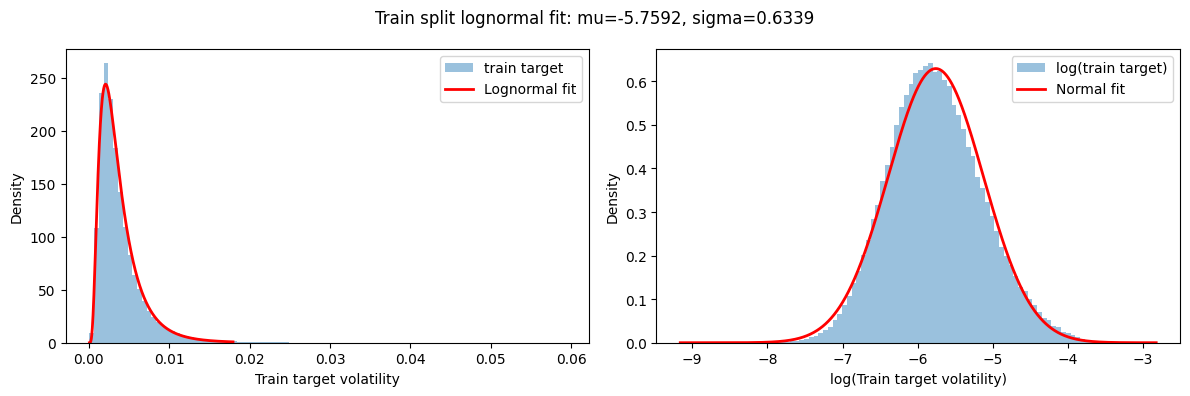

In [4]:
target = train_split["target"].dropna()
shape, loc, scale = lognorm.fit(target, floc=0)
mu = np.log(scale)
sigma = shape

x = np.linspace(target.min(), target.quantile(0.995), 1000)
log_target = np.log(target)
log_x = np.linspace(log_target.min(), log_target.max(), 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=100, density=True, alpha=0.45, label="train target")
axes[0].plot(x, lognorm.pdf(x, shape, loc=loc, scale=scale), color="red", linewidth=2, label="Lognormal fit")
axes[0].set_xlabel("Train target volatility")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(log_target, bins=100, density=True, alpha=0.45, label="log(train target)")
axes[1].plot(log_x, norm.pdf(log_x, mu, sigma), color="red", linewidth=2, label="Normal fit")
axes[1].set_xlabel("log(Train target volatility)")
axes[1].set_ylabel("Density")
axes[1].legend()


fig.suptitle(f"Train split lognormal fit: mu={mu:.4f}, sigma={sigma:.4f}")
plt.tight_layout()
plt.show()


In [5]:
stock_id = 0
time_id = train_time_ids[0]

book = pd.read_parquet(
    f"../../data/optiver_volatility/book_train.parquet/stock_id={stock_id}"
)

trade = pd.read_parquet(
    f"../../data/optiver_volatility/trade_train.parquet/stock_id={stock_id}"
)

target = train.loc[
    (train["stock_id"] == stock_id) &
    (train["time_id"] == time_id),
    "target"
].iloc[0]



print(f"stock_id = {stock_id}")
print(f"time_id  = {time_id}")
print(f"target   = {target}")



print("\nBOOK DATA")
print(book.shape)

display(book[book["time_id"] == time_id])

print("\nTRADE DATA")
display(trade[trade["time_id"] == time_id])



stock_id = 0
time_id  = 5
target   = 0.004135767

BOOK DATA
(917553, 10)


,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.001370,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.001370,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.001370,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.001370,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.001370,1.002405,3,126,2,100
...,...,...,...,...,...,...,...,...,...,...
297,5,585,1.003129,1.003749,1.003025,1.003801,100,3,26,3
298,5,586,1.003129,1.003749,1.002612,1.003801,100,3,2,3
299,5,587,1.003129,1.003749,1.003025,1.003801,100,3,26,3
300,5,588,1.003129,1.003749,1.002612,1.003801,100,3,2,3



TRADE DATA


,time_id,seconds_in_bucket,price,size,order_count
0,5,21,1.002301,326,12
1,5,46,1.002778,128,4
2,5,50,1.002818,55,1
3,5,57,1.003155,121,5
4,5,68,1.003646,4,1
5,5,78,1.003762,134,5
6,5,122,1.004207,102,3
7,5,127,1.004577,1,1
8,5,144,1.004370,6,1
9,5,147,1.003964,233,4


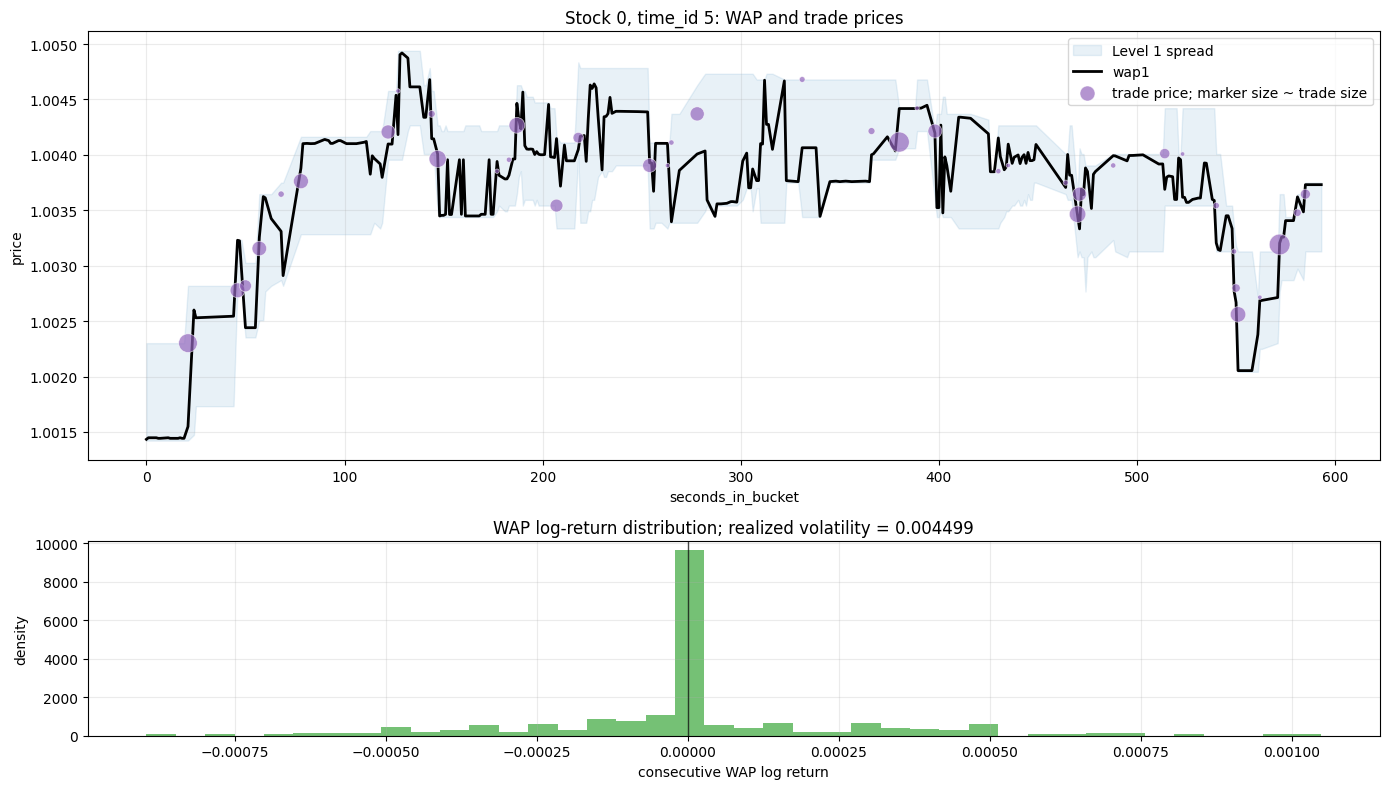

In [6]:
book_slice = book[book["time_id"] == time_id].copy()
trade_slice = trade[trade["time_id"] == time_id].copy()

book_slice["wap1"] = (
    book_slice["bid_price1"] * book_slice["ask_size1"]
    + book_slice["ask_price1"] * book_slice["bid_size1"]
) / (book_slice["bid_size1"] + book_slice["ask_size1"])
book_slice["wap1_log_return"] = np.log(book_slice["wap1"]).diff()
wap_log_returns = book_slice["wap1_log_return"].dropna()
realized_volatility = np.sqrt(np.sum(wap_log_returns ** 2))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2.2, 1]})
price_ax, return_ax = axes

price_ax.fill_between(
     book_slice["seconds_in_bucket"],
     book_slice["bid_price1"],
     book_slice["ask_price1"],
     color="tab:blue",
     alpha=0.10,
     label="Level 1 spread",
 )
# price_ax.plot(book_slice["seconds_in_bucket"], book_slice["bid_price1"], color="tab:blue", linewidth=1.4, label="bid_price1")
# price_ax.plot(book_slice["seconds_in_bucket"], book_slice["ask_price1"], color="tab:red", linewidth=1.4, label="ask_price1")
price_ax.plot(book_slice["seconds_in_bucket"], book_slice["wap1"], color="black", linewidth=2.0, label="wap1")

if not trade_slice.empty:
    trade_sizes = np.sqrt(trade_slice["size"].clip(lower=1)) * 10
    price_ax.scatter(
        trade_slice["seconds_in_bucket"],
        trade_slice["price"],
        s=trade_sizes,
        color="tab:purple",
        alpha=0.70,
        edgecolors="white",
        linewidths=0.5,
        label="trade price; marker size ~ trade size",
        zorder=5,
    )

price_ax.set_title(f"Stock {stock_id}, time_id {time_id}: WAP and trade prices")
price_ax.set_xlabel("seconds_in_bucket")
price_ax.set_ylabel("price")
price_ax.grid(True, alpha=0.25)
price_ax.legend(loc="best")

return_ax.hist(wap_log_returns, bins=40, density=True, alpha=0.65, color="tab:green")
return_ax.axvline(0, color="black", linewidth=1.0, alpha=0.7)
return_ax.set_title(f"WAP log-return distribution; realized volatility = {realized_volatility:.6f}")
return_ax.set_xlabel("consecutive WAP log return")
return_ax.set_ylabel("density")
return_ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


,split,rows,r2,rmspe
0,train_split,214465,0.622455,0.338185
1,test_split,214467,0.634029,0.344495


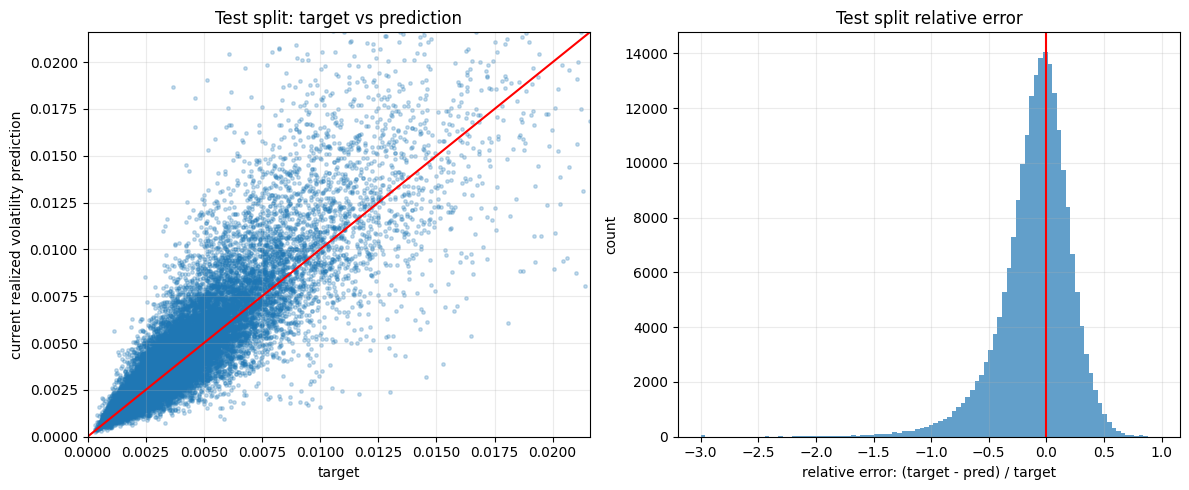

In [7]:
from pathlib import Path
from sklearn.metrics import r2_score

DATA_DIR = Path("../../data/optiver_volatility")

def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

def realized_volatility(series_log_return):
    return np.sqrt(np.sum(series_log_return ** 2))

def realized_volatility_per_stock(stock_id):
    df_book = pd.read_parquet(DATA_DIR / "book_train.parquet" / f"stock_id={stock_id}")
    df_book["wap"] = (
        df_book["bid_price1"] * df_book["ask_size1"]
        + df_book["ask_price1"] * df_book["bid_size1"]
    ) / (df_book["bid_size1"] + df_book["ask_size1"])
    df_book["log_return"] = df_book.groupby("time_id")["wap"].transform(lambda x: np.log(x).diff())
    df_book = df_book.dropna(subset=["log_return"])

    df_rv = df_book.groupby("time_id")["log_return"].agg(realized_volatility).reset_index()
    df_rv = df_rv.rename(columns={"log_return": "pred"})
    df_rv["stock_id"] = stock_id
    return df_rv[["stock_id", "time_id", "pred"]]

df_current_rv = pd.concat(
    [realized_volatility_per_stock(stock_id) for stock_id in sorted(train["stock_id"].unique())],
    ignore_index=True,
)

train_eval = train_split.merge(df_current_rv, on=["stock_id", "time_id"], how="left").dropna(subset=["pred"])
test_eval = test_split.merge(df_current_rv, on=["stock_id", "time_id"], how="left").dropna(subset=["pred"])

scores = pd.DataFrame(
    [
        {
            "split": "train_split",
            "rows": len(train_eval),
            "r2": r2_score(train_eval["target"], train_eval["pred"]),
            "rmspe": rmspe(train_eval["target"], train_eval["pred"]),
        },
        {
            "split": "test_split",
            "rows": len(test_eval),
            "r2": r2_score(test_eval["target"], test_eval["pred"]),
            "rmspe": rmspe(test_eval["target"], test_eval["pred"]),
        },
    ]
)
display(scores)

plot_df = test_eval.sample(min(len(test_eval), 30000), random_state=42)
rel_error = (test_eval["target"] - test_eval["pred"]) / test_eval["target"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(plot_df["target"], plot_df["pred"], s=6, alpha=0.25)
limit = max(plot_df["target"].quantile(0.995), plot_df["pred"].quantile(0.995))
axes[0].plot([0, limit], [0, limit], color="red", linewidth=1.5)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("target")
axes[0].set_ylabel("current realized volatility prediction")
axes[0].set_title("Test split: target vs prediction")
axes[0].grid(True, alpha=0.25)

axes[1].hist(rel_error.clip(-3, 3), bins=100, alpha=0.70)
axes[1].axvline(0, color="red", linewidth=1.5)
axes[1].set_xlabel("relative error: (target - pred) / target")
axes[1].set_ylabel("count")
axes[1].set_title("Test split relative error")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


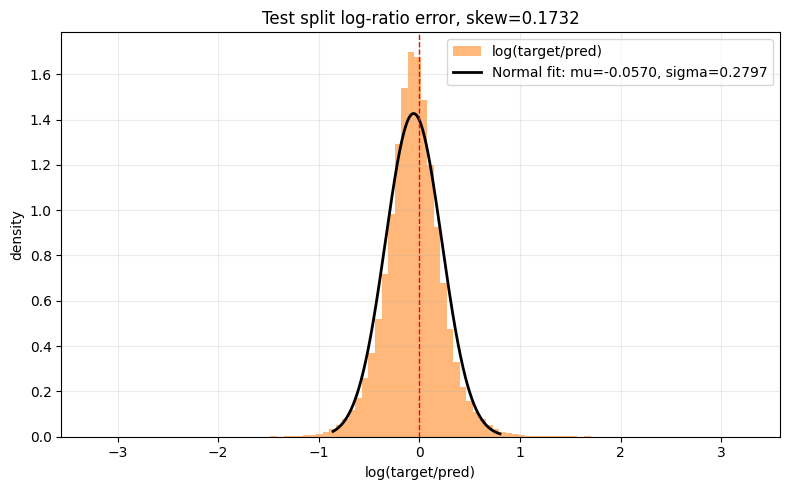

In [10]:
from scipy.stats import norm

log_ratio = np.log(test_eval["target"] / test_eval["pred"])
mu, sigma = norm.fit(log_ratio)
x = np.linspace(log_ratio.quantile(0.005), log_ratio.quantile(0.995), 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(log_ratio, bins=100, density=True, alpha=0.55, color="tab:orange", label="log(target/pred)")
ax.plot(x, norm.pdf(x, mu, sigma), color="black", linewidth=2, label=f"Normal fit: mu={mu:.4f}, sigma={sigma:.4f}")
ax.axvline(0, color="red", linewidth=1.0, linestyle="--")
ax.set_xlabel("log(target/pred)")
ax.set_ylabel("density")
ax.set_title(f"Test split log-ratio error, skew={log_ratio.skew():.4f}")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [17]:

# Single-stock, whole-window feature engineering (reuses book/trade already loaded for stock_id=0)
b = book.copy()
b["wap1"] = (b["bid_price1"] * b["ask_size1"] + b["ask_price1"] * b["bid_size1"]) / (b["bid_size1"] + b["ask_size1"])
b["wap2"] = (b["bid_price2"] * b["ask_size2"] + b["ask_price2"] * b["bid_size2"]) / (b["bid_size2"] + b["ask_size2"])
b["spread"] = (b["ask_price1"] - b["bid_price1"]) / b["wap1"]
b["imbalance"] = (b["bid_size1"] - b["ask_size1"]) / (b["bid_size1"] + b["ask_size1"])
b["ret1"] = b.groupby("time_id")["wap1"].transform(lambda s: np.log(s).diff())
b["ret2"] = b.groupby("time_id")["wap2"].transform(lambda s: np.log(s).diff())

book_feats = b.groupby("time_id").apply(lambda g: pd.Series({
    "rv_wap1": np.sqrt(np.sum(g["ret1"].dropna() ** 2)),
    "rv_wap2": np.sqrt(np.sum(g["ret2"].dropna() ** 2)),
    "spread_mean": g["spread"].mean(),
    "spread_std": g["spread"].std(),
    "imbalance_mean": g["imbalance"].mean(),
    "imbalance_std": g["imbalance"].std(),
    "n_updates": len(g),
    "wap_range": (g["wap1"].max() - g["wap1"].min()) / g["wap1"].mean(),
}), include_groups=False).reset_index()

t = trade.copy()
t["trade_ret"] = t.groupby("time_id")["price"].transform(lambda s: np.log(s).diff())
trade_feats = t.groupby("time_id").apply(lambda g: pd.Series({
    "trade_count": len(g),
    "trade_volume": g["size"].sum(),
    "avg_trade_size": g["size"].mean(),
    "rv_trade": np.sqrt(np.sum(g["trade_ret"].dropna() ** 2)),
}), include_groups=False).reset_index()

features = book_feats.merge(trade_feats, on="time_id", how="left")
features[["trade_count", "trade_volume", "avg_trade_size", "rv_trade"]] = features[
    ["trade_count", "trade_volume", "avg_trade_size", "rv_trade"]
].fillna(0)

print(f"stock_id = {stock_id} | feature rows: {len(features)}")
features.head()


stock_id = 0 | feature rows: 3830


,time_id,rv_wap1,rv_wap2,spread_mean,spread_std,imbalance_mean,imbalance_std,n_updates,wap_range,trade_count,trade_volume,avg_trade_size,rv_trade
0,5,0.004499,0.006999,0.000852,0.000211,-0.006357,0.708949,302.0,0.003473,40.0,3179.0,79.475000,0.002006
1,11,0.001204,0.002476,0.000394,0.000157,0.167165,0.702103,200.0,0.001134,30.0,1289.0,42.966667,0.000901
2,16,0.002369,0.004801,0.000725,0.000164,-0.105494,0.583874,188.0,0.003656,25.0,2161.0,86.440000,0.001961
3,31,0.002574,0.003637,0.000861,0.000280,0.056378,0.709451,120.0,0.002968,15.0,1962.0,130.800000,0.001561
4,62,0.001894,0.003257,0.000397,0.000130,0.088670,0.674933,176.0,0.000928,22.0,1791.0,81.409091,0.000871


In [18]:

# Single-stock, whole-window linear regression: target ~ engineered features
from sklearn.linear_model import LinearRegression

feature_cols = [
    "rv_wap1", "rv_wap2", "spread_mean", "spread_std",
    "imbalance_mean", "imbalance_std", "n_updates", "wap_range",
    "trade_count", "trade_volume", "rv_trade",
]

stock_target = train.loc[train["stock_id"] == stock_id, ["time_id", "target"]]
data = features.merge(stock_target, on="time_id", how="inner").dropna(subset=feature_cols)

train_data = data[data["time_id"].isin(train_time_ids)]
test_data = data[data["time_id"].isin(test_time_ids)]

lr = LinearRegression()
lr.fit(train_data[feature_cols], train_data["target"])

train_pred = lr.predict(train_data[feature_cols])
test_pred = lr.predict(test_data[feature_cols])

naive_test_rmspe = rmspe(test_data["target"], test_data["rv_wap1"])

print(f"stock_id = {stock_id} | train rows: {len(train_data)} | test rows: {len(test_data)}\n")
print("linear regression on engineered features:")
print(f"  train  r2={r2_score(train_data['target'], train_pred):.4f}  rmspe={rmspe(train_data['target'], train_pred):.4f}")
print(f"  test   r2={r2_score(test_data['target'], test_pred):.4f}  rmspe={rmspe(test_data['target'], test_pred):.4f}")
print(f"\nnaive rv_wap1 baseline (test): rmspe={naive_test_rmspe:.4f}")


stock_id = 0 | train rows: 1915 | test rows: 1915

linear regression on engineered features:
  train  r2=0.7601  rmspe=0.3150
  test   r2=0.7478  rmspe=0.3378

naive rv_wap1 baseline (test): rmspe=0.4062


In [21]:

# All-stocks, whole-window feature engineering (features computed independently per stock)
def compute_stock_features(stock_id):
    b = pd.read_parquet(DATA_DIR / "book_train.parquet" / f"stock_id={stock_id}")
    b["wap1"] = (b["bid_price1"] * b["ask_size1"] + b["ask_price1"] * b["bid_size1"]) / (b["bid_size1"] + b["ask_size1"])
    b["wap2"] = (b["bid_price2"] * b["ask_size2"] + b["ask_price2"] * b["bid_size2"]) / (b["bid_size2"] + b["ask_size2"])
    b["spread"] = (b["ask_price1"] - b["bid_price1"]) / b["wap1"]
    b["imbalance"] = (b["bid_size1"] - b["ask_size1"]) / (b["bid_size1"] + b["ask_size1"])
    b["ret1"] = b.groupby("time_id")["wap1"].transform(lambda s: np.log(s).diff())
    b["ret2"] = b.groupby("time_id")["wap2"].transform(lambda s: np.log(s).diff())

    book_feats = b.groupby("time_id").agg(
        rv_wap1=("ret1", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
        rv_wap2=("ret2", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
        spread_mean=("spread", "mean"),
        spread_std=("spread", "std"),
        imbalance_mean=("imbalance", "mean"),
        imbalance_std=("imbalance", "std"),
        n_updates=("wap1", "size"),
        wap1_min=("wap1", "min"),
        wap1_max=("wap1", "max"),
        wap1_mean=("wap1", "mean"),
    ).reset_index()
    book_feats["wap_range"] = (book_feats["wap1_max"] - book_feats["wap1_min"]) / book_feats["wap1_mean"]
    book_feats = book_feats.drop(columns=["wap1_min", "wap1_max", "wap1_mean"])

    t = pd.read_parquet(DATA_DIR / "trade_train.parquet" / f"stock_id={stock_id}")
    t["trade_ret"] = t.groupby("time_id")["price"].transform(lambda s: np.log(s).diff())
    trade_feats = t.groupby("time_id").agg(
        trade_count=("price", "size"),
        trade_volume=("size", "sum"),
        rv_trade=("trade_ret", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
    ).reset_index()

    feats = book_feats.merge(trade_feats, on="time_id", how="left")
    feats[["trade_count", "trade_volume", "rv_trade"]] = feats[["trade_count", "trade_volume", "rv_trade"]].fillna(0)
    feats["stock_id"] = stock_id
    return feats

all_features = pd.concat(
    [compute_stock_features(sid) for sid in sorted(train["stock_id"].unique())],
    ignore_index=True,
)
print(f"all_features rows: {len(all_features):,} | stocks: {all_features['stock_id'].nunique()}")
all_features.head()


all_features rows: 428,932 | stocks: 112


,time_id,rv_wap1,rv_wap2,spread_mean,spread_std,imbalance_mean,imbalance_std,n_updates,wap_range,trade_count,trade_volume,rv_trade,stock_id
0,5,0.004499,0.006999,0.000852,0.000211,-0.006357,0.708949,302,0.003473,40.0,3179.0,0.002006,0
1,11,0.001204,0.002476,0.000394,0.000157,0.167165,0.702103,200,0.001134,30.0,1289.0,0.000901,0
2,16,0.002369,0.004801,0.000725,0.000164,-0.105494,0.583874,188,0.003656,25.0,2161.0,0.001961,0
3,31,0.002574,0.003637,0.000861,0.000280,0.056378,0.709451,120,0.002968,15.0,1962.0,0.001561,0
4,62,0.001894,0.003257,0.000397,0.000130,0.088670,0.674933,176,0.000928,22.0,1791.0,0.000871,0


In [22]:

# All-stocks, whole-window pooled linear regression: target ~ engineered features, weighted by 1/target^2 to align the OLS loss with RMSPE
data_all = all_features.merge(train[["stock_id", "time_id", "target"]], on=["stock_id", "time_id"], how="inner").dropna(subset=feature_cols)

train_all = data_all[data_all["time_id"].isin(train_time_ids)]
test_all = data_all[data_all["time_id"].isin(test_time_ids)]

lr_all = LinearRegression()
lr_all.fit(train_all[feature_cols], train_all["target"], sample_weight=1.0 / train_all["target"] ** 2)

train_all_pred = lr_all.predict(train_all[feature_cols])
test_all_pred = lr_all.predict(test_all[feature_cols])

print(f"all stocks | train rows: {len(train_all):,} | test rows: {len(test_all):,}\n")
print("pooled linear regression on engineered features (weighted by 1/target^2):")
print(f"  train  r2={r2_score(train_all['target'], train_all_pred):.4f}  rmspe={rmspe(train_all['target'], train_all_pred):.4f}")
print(f"  test   r2={r2_score(test_all['target'], test_all_pred):.4f}  rmspe={rmspe(test_all['target'], test_all_pred):.4f}")
print(f"\nnaive rv_wap1 baseline (test, all stocks): rmspe={rmspe(test_eval['target'], test_eval['pred']):.4f}")


all stocks | train rows: 214,465 | test rows: 214,467

pooled linear regression on engineered features (weighted by 1/target^2):
  train  r2=0.7419  rmspe=0.2595
  test   r2=0.7514  rmspe=0.2605

naive rv_wap1 baseline (test, all stocks): rmspe=0.3445


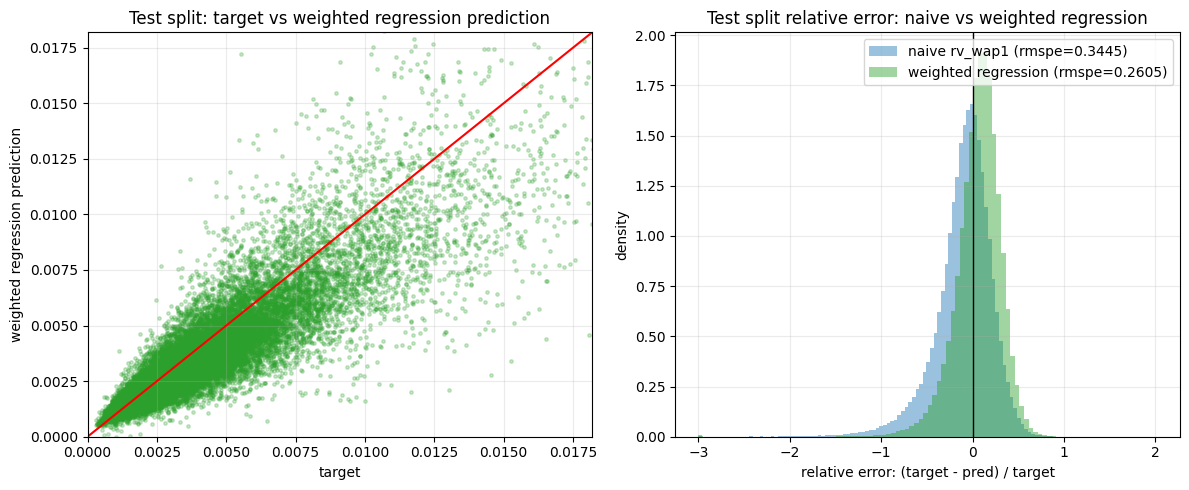

In [23]:

# Visualize weighted-regression results vs naive baseline (test split, all stocks)
test_compare = test_all.assign(pred_lr=test_all_pred).merge(
    test_eval[["stock_id", "time_id", "pred"]], on=["stock_id", "time_id"], how="inner"
)

rel_error_lr = (test_compare["target"] - test_compare["pred_lr"]) / test_compare["target"]
rel_error_naive = (test_compare["target"] - test_compare["pred"]) / test_compare["target"]

plot_sample = test_compare.sample(min(len(test_compare), 30000), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(plot_sample["target"], plot_sample["pred_lr"], s=6, alpha=0.25, color="tab:green")
limit = max(plot_sample["target"].quantile(0.995), plot_sample["pred_lr"].quantile(0.995))
axes[0].plot([0, limit], [0, limit], color="red", linewidth=1.5)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("target")
axes[0].set_ylabel("weighted regression prediction")
axes[0].set_title("Test split: target vs weighted regression prediction")
axes[0].grid(True, alpha=0.25)

axes[1].hist(rel_error_naive.clip(-3, 3), bins=100, density=True, alpha=0.45, color="tab:blue",
             label=f"naive rv_wap1 (rmspe={rmspe(test_compare['target'], test_compare['pred']):.4f})")
axes[1].hist(rel_error_lr.clip(-3, 3), bins=100, density=True, alpha=0.45, color="tab:green",
             label=f"weighted regression (rmspe={rmspe(test_compare['target'], test_compare['pred_lr']):.4f})")
axes[1].axvline(0, color="black", linewidth=1.0)
axes[1].set_xlabel("relative error: (target - pred) / target")
axes[1].set_ylabel("density")
axes[1].set_title("Test split relative error: naive vs weighted regression")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
